# Notebook 2 Test Analysis

Use this notebook for experimental result analysis and new plotting methods.
The production catalog and canonical matching diagnostics are generated by
`2_singphotandmatching.ipynb`.


## 1. Load Catalogs


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.wcs import FITSFixedWarning

warnings.filterwarnings("ignore", category=FITSFixedWarning)


def project_root():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "Notebooks" else cwd


PROJECT_ROOT = project_root()
COSMOS = 1
BANDS_7DT = [f"m{i}" for i in range(400, 900, 25)]
MATCH_DIR = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot/matching"
FIG_DIR = MATCH_DIR / "test_figures"

master = Table.read(MATCH_DIR / "master_catalog.fits")
band_uncertainty = Table.read(MATCH_DIR / "band_uncertainty.fits")
matching_diagnostics = Table.read(MATCH_DIR / "matching_diagnostics_7dt.fits")
consistency_diagnostics = Table.read(MATCH_DIR / "consistency_diagnostics_7dt.fits")
finalcat_diagnostics = Table.read(MATCH_DIR / "finalcat_matching_diagnostics.fits")
radius_diagnostics = Table.read(MATCH_DIR / "finalcat_radius_diagnostics.fits")
full20 = Table.read(MATCH_DIR / "master_full20_catalog.fits")

master_class = np.asarray(master["master_class"]).astype(str)
matched = master[master_class == "matched"]
only_7dt = master[master_class == "7dt_only"]
only_finalcat = master[master_class == "finalcat_only"]

print(f"master: {len(master)}")
print(f"matched: {len(matched)}")
print(f"7dt_only: {len(only_7dt)}")
print(f"finalcat_only: {len(only_finalcat)}")
print(f"full20: {len(full20)}")


master: 75259
matched: 2977
7dt_only: 16512
finalcat_only: 55770
full20: 1157


## 2. COSMOS Overlap Region

The following cells restrict the union master catalog to the approximate sky
region covered by both catalogs in the COSMOS image inspection:

```text
149.6 <= RA  <= 150.3
1.7   <= Dec <= 2.3
```

The three subsets are saved as temporary analysis catalogs. They are not new
production catalogs and can be regenerated from `master_catalog.fits`.


In [2]:
RA_MIN, RA_MAX = 149.6, 150.3
DEC_MIN, DEC_MAX = 1.7, 2.3

ra = np.asarray(master["master_ra"], dtype=float)
dec = np.asarray(master["master_dec"], dtype=float)
overlap_mask = (
    (ra >= RA_MIN) & (ra <= RA_MAX)
    & (dec >= DEC_MIN) & (dec <= DEC_MAX)
)

master_overlap = master[overlap_mask]
overlap_class = np.asarray(master_overlap["master_class"]).astype(str)
matched_overlap = master_overlap[overlap_class == "matched"]
only_7dt_overlap = master_overlap[overlap_class == "7dt_only"]
only_finalcat_overlap = master_overlap[overlap_class == "finalcat_only"]

overlap_dir = MATCH_DIR / "test_region"
overlap_dir.mkdir(parents=True, exist_ok=True)
matched_overlap.write(overlap_dir / "matched_overlap.fits", overwrite=True)
only_7dt_overlap.write(overlap_dir / "only_7dt_overlap.fits", overwrite=True)
only_finalcat_overlap.write(overlap_dir / "only_finalcat_overlap.fits", overwrite=True)

print(f"Overlap region: RA {RA_MIN}--{RA_MAX}, Dec {DEC_MIN}--{DEC_MAX}")
print(f"Overlap masters: {len(master_overlap)}")
print(f"  matched: {len(matched_overlap)}")
print(f"  7DT-only: {len(only_7dt_overlap)}")
print(f"  FINALCAT-only: {len(only_finalcat_overlap)}")
print(f"Saved temporary catalogs to {overlap_dir}")


Overlap region: RA 149.6--150.3, Dec 1.7--2.3
Overlap masters: 34989
  matched: 1538
  7DT-only: 3083
  FINALCAT-only: 30368
Saved temporary catalogs to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/test_region


## 3. Detection-image Source Plot

The plotting method below is adapted from the historical
`plot_ImageAndDetectedSources` method in commit `cc8dd24`, but uses the new
union-master columns and the requested `pixel_range`/`source_id` interface.

Usage examples:

```python
# Display the whole detection image and all sources in a catalog.
plot_SourceImgFromCatalog(only_7dt_overlap)

# Select a random source and display a 300 x 300 pixel neighborhood.
plot_SourceImgFromCatalog(only_7dt_overlap, pixel_range=150)

# Display a specific master source and its 200 x 200 pixel neighborhood.
plot_SourceImgFromCatalog(
    matched_overlap,
    pixel_range=100,
    source_id=12345,
)
```

The function interprets `source_id` as `master_id`. If `source_id=None`, one
row is selected reproducibly at random. If `pixel_range=None`, the whole image
is displayed. Otherwise, `pixel_range` is the half-width in pixels around the
selected source, so `pixel_range=150` produces approximately a 300 x 300 pixel
view. The ZScale normalization is calculated from the full detection image,
not from each cropped image, so different plots use the same image-level scale.

The selected source is marked with a cyan cross. Other sources in the supplied
catalog are marked with the catalog class color. Image-edge crops are clipped
to the valid image boundaries.


In [5]:
# Usage notes before the function definition:
#
# plot_SourceImgFromCatalog(cat)
#     Plot the whole detection image and all rows in cat.
#
# plot_SourceImgFromCatalog(cat, pixel_range=150)
#     Pick one reproducible random master_id and plot a neighborhood with
#     approximately 150 pixels on each side of that source.
#
# plot_SourceImgFromCatalog(cat, pixel_range=100, source_id=12345)
#     Find master_id=12345 in cat and plot approximately 100 pixels on each
#     side. The source_id argument refers to master_id, not a single-band
#     source_id.
#
# pixel_range=None means whole-image display. The ZScale interval is always
# computed from the full detection image before any crop is applied.
# The input catalog must contain master_id, master_x, master_y, and preferably
# master_class. Coordinates in master_x/master_y use the FITS 1-based convention;
# NumPy crop indices are converted to 0-based internally.

from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval

detection_image_path = PROJECT_ROOT / f"COSMOS_data/COSMOS{COSMOS}/COSMOS1_detectionimage.fits"
detection_image = fits.getdata(detection_image_path)


def plot_SourceImgFromCatalog(cat, image=None, pixel_range=None, source_id=None):
    # Plot a catalog on the detection image, optionally centered on one source.
    if image is None:
        image = detection_image
    if len(cat) == 0:
        raise ValueError("The input catalog is empty.")
    required = {"master_id", "master_x", "master_y"}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f"Catalog is missing required columns: {sorted(missing)}")
    if pixel_range is not None and (not np.isfinite(pixel_range) or pixel_range <= 0):
        raise ValueError("pixel_range must be None or a positive number.")

    master_ids = np.asarray(cat["master_id"], dtype=np.int64)
    if source_id is None:
        rng = np.random.default_rng()
        selected_index = int(rng.integers(len(cat)))
    else:
        matches = np.flatnonzero(master_ids == int(source_id))
        if len(matches) == 0:
            raise KeyError(f"master_id={source_id} is not present in the catalog.")
        selected_index = int(matches[0])

    x_all = np.ma.filled(cat["master_x"], np.nan).astype(float)
    y_all = np.ma.filled(cat["master_y"], np.nan).astype(float)
    selected_x = float(x_all[selected_index])
    selected_y = float(y_all[selected_index])
    if not np.isfinite(selected_x) or not np.isfinite(selected_y):
        raise ValueError("The selected source has a non-finite pixel position.")

    if pixel_range is None:
        xmin, xmax = 0, image.shape[1]
        ymin, ymax = 0, image.shape[0]
    else:
        center_x = int(round(selected_x - 1))
        center_y = int(round(selected_y - 1))
        half = int(round(pixel_range))
        xmin = max(0, center_x - half)
        xmax = min(image.shape[1], center_x + half + 1)
        ymin = max(0, center_y - half)
        ymax = min(image.shape[0], center_y + half + 1)

    finite = np.isfinite(x_all) & np.isfinite(y_all)
    in_view = finite & (
        (x_all - 1 >= xmin) & (x_all - 1 < xmax)
        & (y_all - 1 >= ymin) & (y_all - 1 < ymax)
    )
    crop = image[ymin:ymax, xmin:xmax]
    norm = ImageNormalize(image, interval=ZScaleInterval())
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(
        crop,
        origin="lower",
        cmap="gray",
        norm=norm,
        extent=[xmin + 1, xmax + 1, ymin + 1, ymax + 1],
    )

    default_color = "tab:red"
    class_colors = {"matched": "black", "7dt_only": "tab:red", "finalcat_only": "tab:blue"}
    if "master_class" in cat.colnames:
        classes = np.asarray(cat["master_class"]).astype(str)
    else:
        classes = np.full(len(cat), "source", dtype="U16")
    for index in np.flatnonzero(in_view):
        ax.scatter(
            x_all[index], y_all[index], s=24, facecolors="none",
            edgecolors=class_colors.get(classes[index], default_color), linewidths=0.8,
        )

    ax.scatter(
        selected_x, selected_y, marker="+", s=180, color="cyan", linewidths=1.5,
        label=f"master_id={master_ids[selected_index]}",
    )
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    title_class = classes[selected_index]
    view_label = "whole image" if pixel_range is None else f"pixel_range={pixel_range}"
    ax.set_title(f"{title_class}: master_id={master_ids[selected_index]} ({view_label})")
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()
    return fig, ax, int(master_ids[selected_index])


## 4. Example Population Views


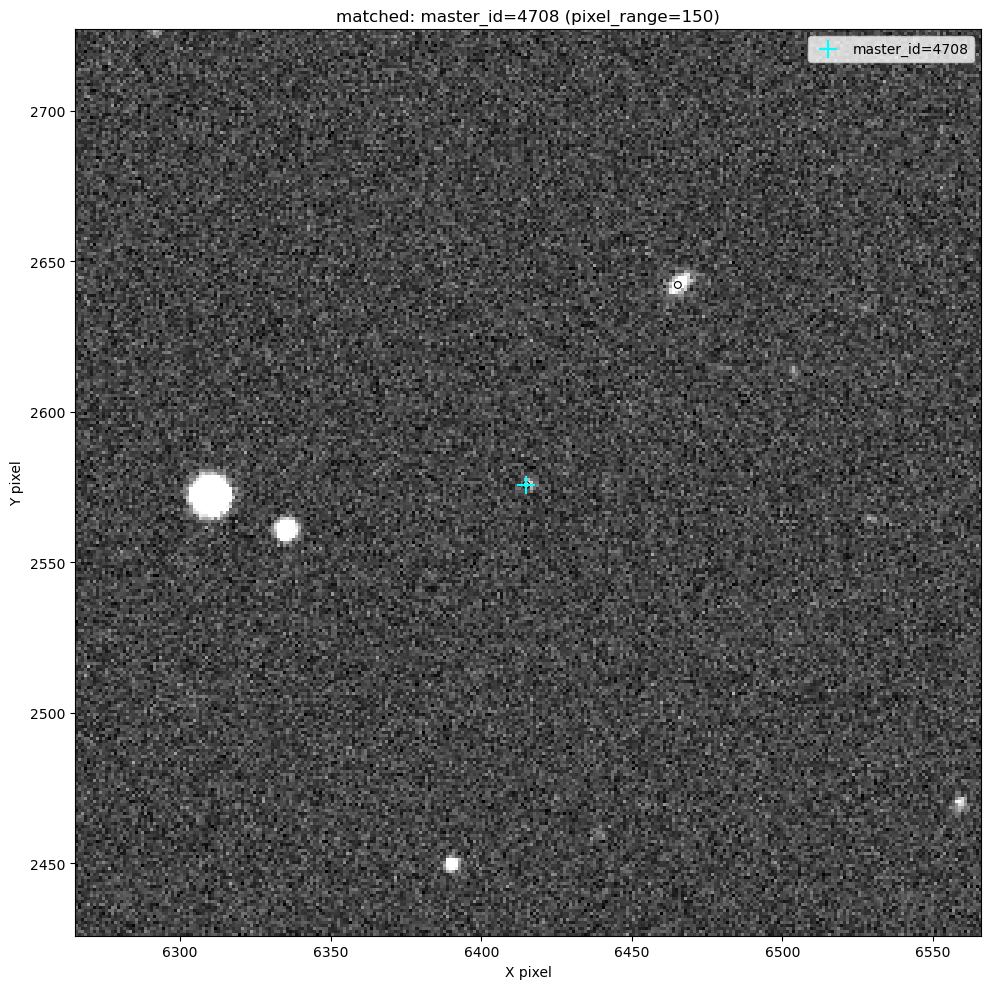

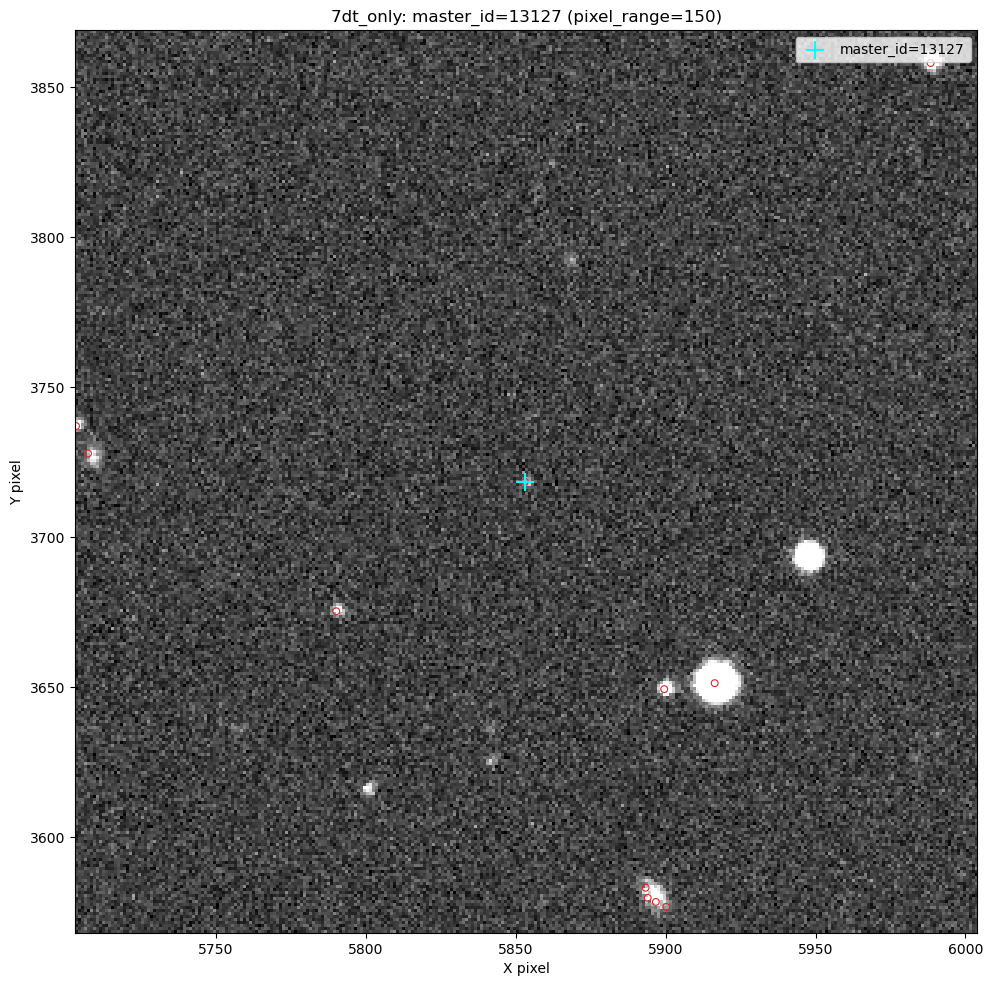

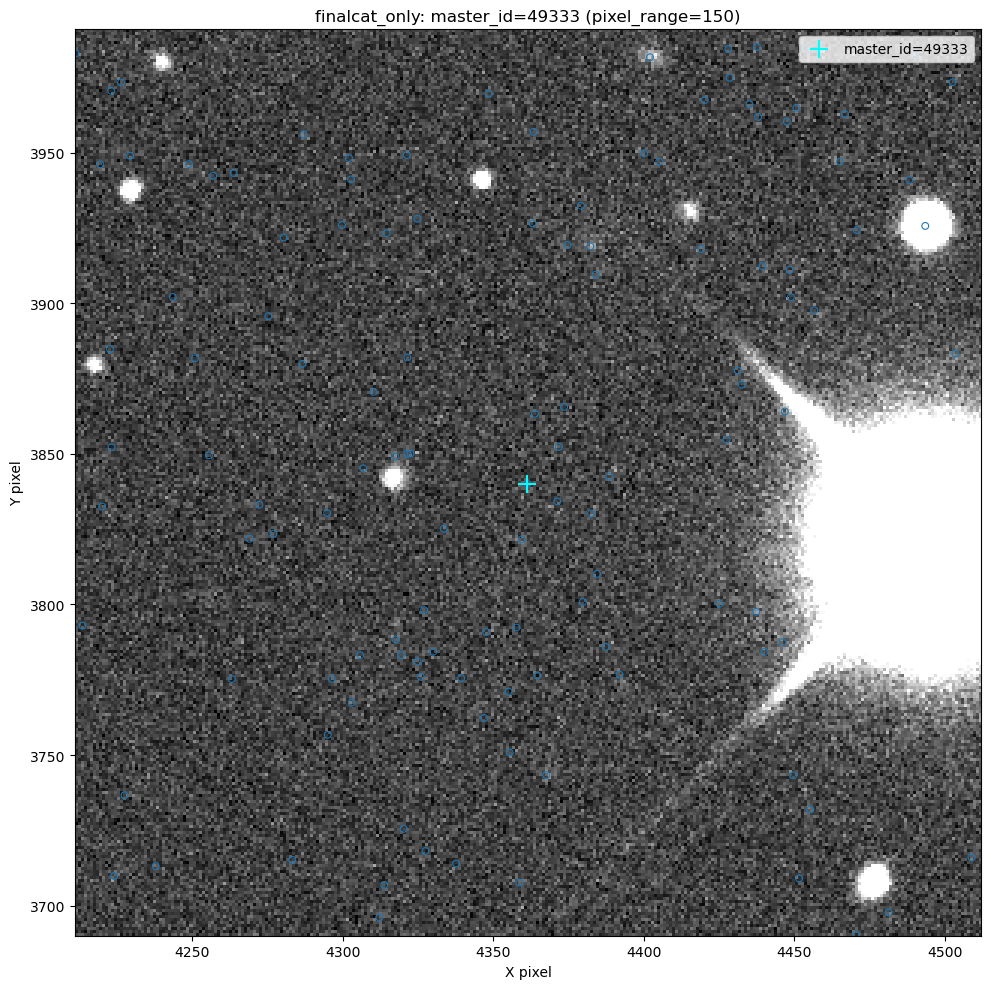

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'finalcat_only: master_id=49333 (pixel_range=150)'}, xlabel='X pixel', ylabel='Y pixel'>,
 49333)

In [6]:
plot_SourceImgFromCatalog(matched_overlap, pixel_range=150)
plot_SourceImgFromCatalog(only_7dt_overlap, pixel_range=150)
plot_SourceImgFromCatalog(only_finalcat_overlap, pixel_range=150)


## 2. Experimental Analysis


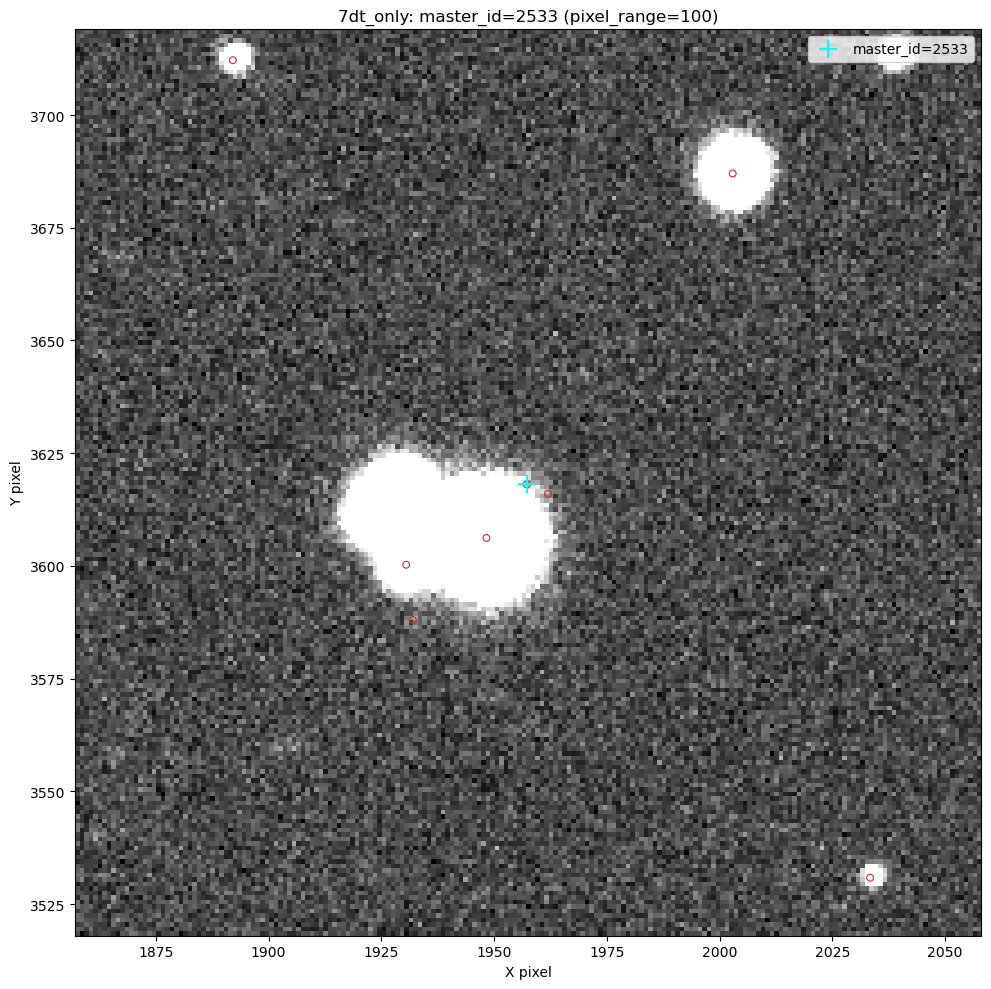

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': '7dt_only: master_id=2533 (pixel_range=100)'}, xlabel='X pixel', ylabel='Y pixel'>,
 2533)

In [52]:
# Add analysis and plotting methods here.
plot_SourceImgFromCatalog(only_7dt_overlap, pixel_range=100)